# Machine learning amb el joc 2048

El famós joc 2048 és una bona base per fer experiments amb algorismes de machine learning. En primer lloc perquè quasi tot en el joc és numèric. Té un espai molt limitat de variables amb una graella de 4x4 i 4 possibles moviments. Té solució amb algorismes tradicionals com MCTS, però té suficient complexitat per a no ser una solució evident. 

Ja comptem amb un joc fet en Javascript que mostra el tauler i juga autonomament amb un algorisme MCTS per decidir el millor moviment. Aquest algorisme explora el arbre de possibles jugades a partir dels 4 moviments. Donat que l'arbre creix exponencialment és molt costós explorar totes les branques fins al 2048 o a perdre, però el MCTS combina una exploració aleatoria amb una exploració exhaustiva per les primeres branques. 

El nostre joc és totalment modificable i permet imprimir en CSV les variables que considerem importants. Com que és molt costós computacionalment, tenim un dataset de dos partides completes en CSV. 

https://arxiv.org/abs/2212.11087 
https://github.com/navjindervirdee/2048-deep-reinforcement-learning

In [48]:
import pandas as pd
import numpy as np
df = pd.read_csv('simulation1.csv')
df.head()

,numSearches,avgCounts,maxCounts,maxDepth,avgMaxs,max,maxBoard,wins0,wins1,wins2,...,board12,board13,board20,board21,board22,board23,board30,board31,board32,board33
0,200,134.16,285,6,120.16,256,4,0.28,0.39,0.33,...,0,0,0,0,0,0,0,2,0,2
1,47,129.42,239,5,116.67,256,4,0.77,0.00,0.22,...,0,0,0,0,0,0,4,2,0,0
2,61,126.82,281,5,107.35,256,4,0.00,0.08,0.29,...,0,0,0,0,0,0,0,0,4,2
3,69,133.00,283,4,116.57,256,8,0.36,0.39,0.11,...,0,0,0,0,0,0,0,0,4,4
4,51,120.04,219,5,101.02,256,8,0.21,0.09,0.36,...,0,0,0,0,0,0,8,0,0,0


In [49]:
df.columns

Index(['numSearches', 'avgCounts', 'maxCounts', 'maxDepth', 'avgMaxs', 'max',
       'maxBoard', 'wins0', 'wins1', 'wins2', 'wins3', 'bestMove', 'board00',
       'board01', 'board02', 'board03', 'board10', 'board11', 'board12',
       'board13', 'board20', 'board21', 'board22', 'board23', 'board30',
       'board31', 'board32', 'board33'],
      dtype='str')

* numSearches: La quantitat de búsquedes que inicia la simulació. A partir de la segona jugada és 450 - avgCount*3. Quan més profundament baixa fem menys búsquedes per mantenir un rendiment acceptable. 
* avgCounts: La mitjana de la profunditat de les simulacions. Generalment amb taulers plens es fan menys perquè moltes acaben perdent abans. 
* maxCounts: Profunditat màxim de les simulacions aleatories. 
* maxDepth: Profunditat màxima de les branques explorades al MCTS
* avgMax: Mitjana de les màximes puntuacions obtingudes en les simulacions.
* max: Màxima puntuació de totes les simulacions.
* maxBoard: El número màxim actual del tauler.
* wins0 - wins3: La puntuació que dona MCTS a cada moviment en funció de la búsqueda de la millor jugada.
* bestMove: millor moviment triat per la simulació.
* board00 - board33: el número actual a la cel·la corresponent (board00 seria board[0][0])

In [50]:
df.describe()

,numSearches,avgCounts,maxCounts,maxDepth,avgMaxs,max,maxBoard,wins0,wins1,wins2,...,board12,board13,board20,board21,board22,board23,board30,board31,board32,board33
count,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,...,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000,11254.000000
mean,351.280522,32.692822,98.208104,8.507553,1602.778326,1646.495824,1589.195486,0.251401,0.248510,0.252721,...,280.992891,112.020970,125.184645,254.948285,262.106273,115.251288,42.271015,140.323085,146.696641,55.981162
std,60.869603,20.224349,51.065476,2.437868,1043.663690,1017.291481,1052.907241,0.275980,0.272138,0.273903,...,666.122567,400.062444,390.414752,595.680085,660.896994,444.861542,235.255058,513.948064,480.639154,303.552196
min,29.000000,0.330000,1.000000,1.000000,96.000000,128.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,324.000000,18.690000,61.000000,7.000000,1024.000000,1024.000000,1024.000000,0.040000,0.040000,0.040000,...,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,365.000000,28.020000,87.000000,8.000000,2042.620000,2048.000000,2048.000000,0.140000,0.150000,0.150000,...,16.000000,2.000000,2.000000,16.000000,16.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,393.000000,41.930000,127.000000,10.000000,2048.000000,2048.000000,2048.000000,0.370000,0.360000,0.380000,...,128.000000,16.000000,16.000000,128.000000,128.000000,16.000000,4.000000,16.000000,16.000000,4.000000
max,448.000000,140.100000,393.000000,26.000000,4096.000000,4096.000000,4096.000000,1.000000,1.000000,1.000000,...,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11254 entries, 0 to 11253
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   numSearches  11254 non-null  int64  
 1   avgCounts    11254 non-null  float64
 2   maxCounts    11254 non-null  int64  
 3   maxDepth     11254 non-null  int64  
 4   avgMaxs      11254 non-null  float64
 5   max          11254 non-null  int64  
 6   maxBoard     11254 non-null  int64  
 7   wins0        11254 non-null  float64
 8   wins1        11254 non-null  float64
 9   wins2        11254 non-null  float64
 10  wins3        11254 non-null  float64
 11  bestMove     11254 non-null  str    
 12  board00      11254 non-null  int64  
 13  board01      11254 non-null  int64  
 14  board02      11254 non-null  int64  
 15  board03      11254 non-null  int64  
 16  board10      11254 non-null  int64  
 17  board11      11254 non-null  int64  
 18  board12      11254 non-null  int64  
 19  board13      11

In [52]:
print(df[["board00", "board01", "board02", "board03", "board10", "board11", "board12", "board13", "board20", "board21", "board22", "board23", "board30", "board31", "board32", "board33", "bestMove"]].info())
no_numeric = pd.to_numeric(df["board31"],errors='coerce').isna()
files_error = df[no_numeric & df["board31"].notna()]

print("Files amb valors no numèrics a la columna:", "board31")
print(files_error)

df[6144:6146]

<class 'pandas.DataFrame'>
RangeIndex: 11254 entries, 0 to 11253
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   board00   11254 non-null  int64
 1   board01   11254 non-null  int64
 2   board02   11254 non-null  int64
 3   board03   11254 non-null  int64
 4   board10   11254 non-null  int64
 5   board11   11254 non-null  int64
 6   board12   11254 non-null  int64
 7   board13   11254 non-null  int64
 8   board20   11254 non-null  int64
 9   board21   11254 non-null  int64
 10  board22   11254 non-null  int64
 11  board23   11254 non-null  int64
 12  board30   11254 non-null  int64
 13  board31   11254 non-null  int64
 14  board32   11254 non-null  int64
 15  board33   11254 non-null  int64
 16  bestMove  11254 non-null  str  
dtypes: int64(16), str(1)
memory usage: 1.5 MB
None
Files amb valors no numèrics a la columna: board31
Empty DataFrame
Columns: [numSearches, avgCounts, maxCounts, maxDepth, avgMaxs, max, maxBoard, w

,numSearches,avgCounts,maxCounts,maxDepth,avgMaxs,max,maxBoard,wins0,wins1,wins2,...,board12,board13,board20,board21,board22,board23,board30,board31,board32,board33
6144,447,0.33,1,2,682.67,2048,2048,0.00,0.50,0.00,...,256,64,2,16,512,4,0,2,2048,16
6145,50,129.71,236,4,109.80,256,4,0.32,0.07,0.29,...,0,0,0,0,0,4,0,0,2,0


## La millor jugada, un problema de classificació

Aquest dataset té algunes columnes que informen de la simulació i altres sobre la decisió del moviment. Depèn del que volem predir pot ser que algunes columnes no siguen necessaries i algunes inclús siguen perjudicials. Per exemple, si mantenim les winX el model predictor de la millor jugada aprendrà sols d'eixes i no estaran disponibles en una partida real. Això és `target leakage`.

Per no fer trampes, un jugador sols té disponible el tauler. Així que construirem un dataset de taules i jugades:

In [53]:
df_game = df[["board00", "board01", "board02", "board03", "board10", "board11", "board12", "board13", "board20", "board21", "board22", "board23", "board30", "board31", "board32", "board33", "bestMove"]]
# Best move és la columna a predir, la convertim a categoria.
df_game["bestMove"] = df_game["bestMove"].astype("category")

# Aplicar el logaritme ($\log_2$) a variables que són potències de 2 converteix una escala exponencial distorsionada en una escala lineal lògica ($1, 2, 3...$). D'aquesta manera reflecteixes el veritable significat de la dada, elimines salts artificials desproporcionats i ajudes qualsevol model (incloent-hi els Random Forests) a trobar patrons de manera molt més estable i precisa.
columnes_to_log = ["board00", "board01", "board02", "board03", "board10", "board11", "board12", "board13", "board20", "board21", "board22", "board23", "board30", "board31", "board32", "board33"]
df_game[columnes_to_log] = np.log2(df_game[columnes_to_log].replace(0, 1))  # Reemplaçar 0 per 1 abans de calcular el logaritme

df_game.tail()

,board00,board01,board02,board03,board10,board11,board12,board13,board20,board21,board22,board23,board30,board31,board32,board33,bestMove
11249,1.0,3.0,9.0,1.0,0.0,11.0,8.0,2.0,6.0,5.0,4.0,6.0,1.0,3.0,10.0,3.0,left
11250,1.0,3.0,9.0,1.0,11.0,8.0,2.0,1.0,6.0,5.0,4.0,6.0,1.0,3.0,10.0,3.0,down
11251,1.0,3.0,9.0,1.0,11.0,8.0,2.0,2.0,6.0,5.0,4.0,6.0,1.0,3.0,10.0,3.0,right
11252,1.0,3.0,9.0,1.0,1.0,11.0,8.0,3.0,6.0,5.0,4.0,6.0,1.0,3.0,10.0,3.0,up
11253,2.0,3.0,9.0,1.0,6.0,11.0,8.0,3.0,1.0,5.0,4.0,6.0,1.0,3.0,10.0,3.0,up


Es tracta d'un problema en que importa la posició de tots els números i no tant la magnitud, per tant no esperem trobar correlacions rellevants que aporten informació a la variable objectiu. Per aquest motiu tampoc sembla que algorismes basats en trobar una línea o polinomi siguen els millors per resoldre aquest tipus de problema. 

Fem la comprovació:

              precision    recall  f1-score   support

        down       0.00      0.00      0.00       551
        left       0.25      0.96      0.40       562
       right       0.28      0.02      0.04       560
          up       0.24      0.02      0.03       578

    accuracy                           0.25      2251
   macro avg       0.19      0.25      0.12      2251
weighted avg       0.19      0.25      0.12      2251



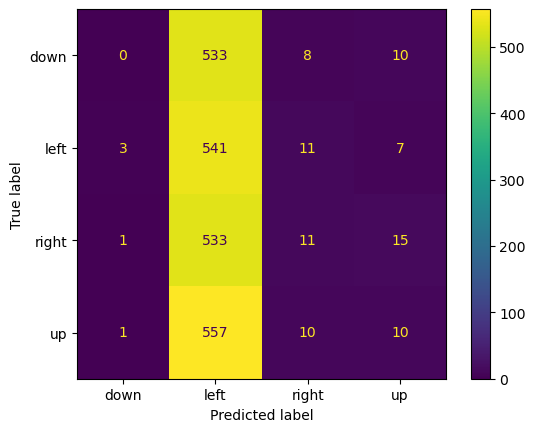

In [54]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X = df_game.drop("bestMove", axis=1)
y = df_game["bestMove"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train)

y_pred = sgd_clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sgd_clf.classes_)
disp.plot()

print(classification_report(y_test, y_pred))

Per avaluar si ens convé més un Random Forest o un KNN en aquest tipus de problema basat en la lògica posicional i estructural, hem de valorar la seva sensibilitat a l'estructura de les dades: tot i que ambdós capturen patrons no lineals de manera excel·lent (previ pas indispensable d'aplicar el $\log_2$ a les potències de 2 per normalitzar les escales), el **KNN** depèn críticament de les distàncies geomètriques i pateix greument la maledicció de la dimensionalitat si tenim moltes columnes, mentre que el **Random Forest** s'hi mostra molt més robust gràcies a la seva capacitat nativa per filtrar el soroll, seleccionar les variables clau i prendre decisions basades en regles combinatòries sense dependre d'un espai mètric rígid.

              precision    recall  f1-score   support

        down       0.24      0.24      0.24       551
        left       0.27      0.23      0.25       562
       right       0.27      0.28      0.27       560
          up       0.29      0.34      0.31       578

    accuracy                           0.27      2251
   macro avg       0.27      0.27      0.27      2251
weighted avg       0.27      0.27      0.27      2251



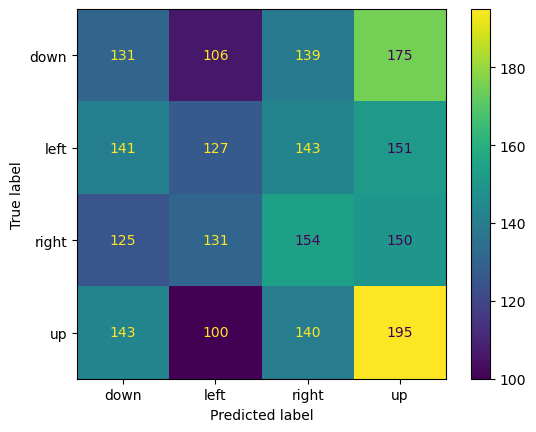

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test) 

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sgd_clf.classes_)
disp.plot()

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        down       0.23      0.32      0.27       551
        left       0.26      0.27      0.26       562
       right       0.21      0.19      0.20       560
          up       0.24      0.16      0.20       578

    accuracy                           0.23      2251
   macro avg       0.23      0.23      0.23      2251
weighted avg       0.23      0.23      0.23      2251



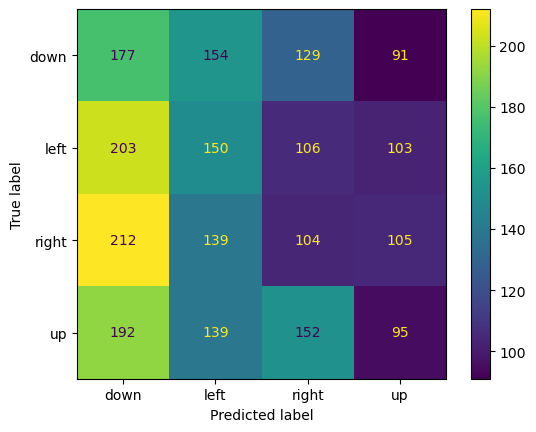

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sgd_clf.classes_)
disp.plot()

print(classification_report(y_test, y_pred))

Els arbres o K-nn no "entenen" el problema, sols repeteixen el que han vist a l'entrenament. Una possible solució és donar més informació espacial com el número màxim i on està, els números iguals adjacents... Una altra solució pot ser ampliar el dataset amb moltes més combinacions en tots els estats del joc i una altra canviar d'estratègia cap a un `reinforcement learning` o `Deep learning`

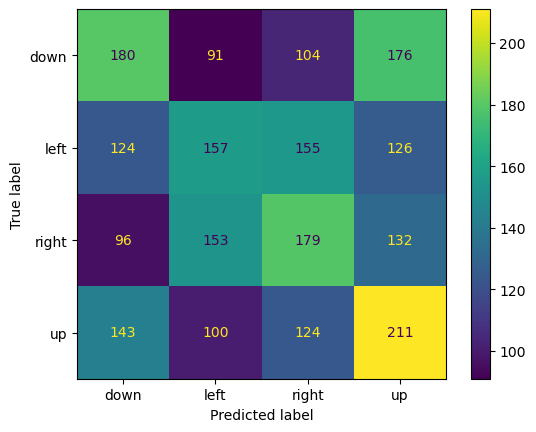

In [59]:
from sklearn.ensemble import HistGradientBoostingClassifier


def extreure_caracteristiques_2048(df_16_cols):
    # Passem les columnes a una matriu 3D de (n_mostres, 4, 4)
    taulells = df_16_cols.values.reshape(-1, 4, 4)
    
    noves_features = []
    for t in taulells:
        zeros = np.sum(t == 0)                          # 1. Caselles buides
        max_val = np.max(t)                             # 2. Valor màxim
        
        # 3. Comprovar parells iguals adjacents (horitzontal i vertical)
        match_h = np.sum(t[:, :-1] == t[:, 1:])         # Coincidències horitzontals
        match_v = np.sum(t[:-1, :] == t[1:, :])         # Coincidències verticals
        
        # 4. On està el màxim? ( cantonada o no )
        # Comprovem si el màxim està a alguna de les 4 cantonades
        es_cantonada = 1 if (t[0,0] == max_val or t[0,3] == max_val or t[3,0] == max_val or t[3,3] == max_val) else 0

        # 5. Sumes de files i columnes
        #noves_features.append([zeros, max_val, match_h, match_v, es_cantonada])

        # Dins del teu bucle per cada taulell 't' (matriu 4x4):
        sumes_files = t.sum(axis=1)   # Retorna un array de 4 valors (un per cada fila)
        sumes_cols = t.sum(axis=0)    # Retorna un array de 4 valors (un per cada columna)

        # Pots concatenar-ho tot a la llista de noves features:
        noves_features.append(
            [zeros, max_val, match_h, match_v, es_cantonada] + 
            list(sumes_files) + 
            list(sumes_cols)
        )
        
    df_espacial = pd.DataFrame(noves_features, columns=['zeros', 'max_val', 'match_h', 'match_v', 'es_cantonada', 'suma_file_1', 'suma_file_2', 'suma_file_3', 'suma_file_4', 'suma_col_1', 'suma_col_2', 'suma_col_3', 'suma_col_4'])
    
    # Unim les 16 columnes originals amb aquestes noves mètriques espacials
    return pd.concat([df_16_cols.reset_index(drop=True), df_espacial.reset_index(drop=True)], axis=1)

# Apliquem la transformació a train i test
X_train_enriquit = extreure_caracteristiques_2048(X_train)
X_test_enriquit = extreure_caracteristiques_2048(X_test)

hgb_clf = HistGradientBoostingClassifier(max_iter=1000, random_state=42)
hgb_clf.fit(X_train_enriquit, y_train)
y_pred = hgb_clf.predict(X_test_enriquit)
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sgd_clf.classes_)
disp.plot()


In [61]:


print(X_train_enriquit[["zeros", "max_val", "match_h", "match_v", "es_cantonada", "suma_file_1", "suma_file_2", "suma_file_3", "suma_file_4", "suma_col_1", "suma_col_2", "suma_col_3", "suma_col_4"]].tail())

      zeros  max_val  match_h  match_v  es_cantonada  suma_file_1  \
8998      7     11.0        3        2             0          5.0   
8999      4     11.0        1        2             0          3.0   
9000      7     11.0        4        6             0         12.0   
9001      7     10.0        4        4             0         18.0   
9002      4     11.0        1        3             0          7.0   

      suma_file_2  suma_file_3  suma_file_4  suma_col_1  suma_col_2  \
8998         18.0         13.0          6.0        23.0        17.0   
8999          6.0         20.0          7.0         2.0         8.0   
9000         19.0          8.0          2.0         0.0         2.0   
9001         12.0         11.0          0.0        14.0        23.0   
9002         23.0          8.0          3.0         1.0        17.0   

      suma_col_3  suma_col_4  
8998         1.0         1.0  
8999        17.0         9.0  
9000        25.0        14.0  
9001         2.0         2.0  
900

El resultat és molt dolent. No sembla que modificar els hiperparàmetres o triar una altra versió del mateix tipus d'algorismes millore la situació. El principal problema és que no es diferencia molt un bon moviment d'un moviment no òptim en quant al resultat del joc. És molt probable que el mateix algorisme en situacions molts similars trie qualsevol altre moviment si les simulacions han funcionat. Amb un model potent i dades enriquides sembla que guanyen més pes les diagonals. En aquest joc sol ser igualment bó el moviment cap a la dreta o cal a l'esquerra o dalt i baix. Per tant un poc d'aprenentatge sembla que s'ha aconseguit. 

Es pot intentar posar aquest model en producció per veure el seu rendiment en un joc real front a un joc aleatori. 
